# M5 Data — Exploratory Data Analysis

This notebook looks at the raw M5 data **before** any of the cleanup done
in `02_pipeline.ipynb`, and shows *why* each cleanup decision was made.
Every section here ends with a short note pointing to the exact step in
the pipeline notebook that the finding justifies.

Run this notebook independently - it loads the same two raw CSVs the
pipeline uses, and shares the same Parquet cache folder so nothing is
loaded twice unnecessarily.

### Repository layout
This notebook lives in `Code/notebooks/`. It imports shared paths from
`Code/config.py` (so file locations always resolve correctly regardless
of where Jupyter is launched from), and expects the raw M5 CSVs in
`Code/data/m5/` (see `Code/data/README.md` for download instructions).


## Contents
1. [Load the raw files](#1.-Load-the-raw-files)
2. Structure: what does one row actually mean?
3. Reshape a sample to long format, and check the date range
4. How sparse is the data? (Why aggregate to monthly?)
   - 4.5 The first month isn't a real month
5. Why does the hierarchy need a "Total" root?
6. New items: why fix the item universe using training data only?
7. Seasonality: is there a repeating yearly pattern?
8. Volume concentration: the Pareto curve
9. Sales by category and state
   - 9.5 Sales are never negative - so why does the pipeline clip forecasts?
10. Summary — EDA finding → Pipeline decision


In [1]:
import sys
from pathlib import Path
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Code/config.py is the single source of truth for paths shared with
# 02_pipeline.ipynb and the Streamlit app - importing it here means this
# notebook can never silently point at a different data folder than the
# pipeline does.
sys.path.append(str(Path("..").resolve()))
import config as cfg

M5_DATA_DIR = cfg.DATA_DIR
cache_raw_dir = cfg.RAW_CACHE_DIR

plt.rcParams["figure.figsize"] = (10, 4)
print("Imports OK")


Imports OK


## 1. Load the raw files

In [2]:
cache_path = cache_raw_dir / "sales_train_validation.parquet"
if not cache_path.is_file():
    df_sales_raw = pd.read_csv(M5_DATA_DIR / "sales_train_validation.csv")
    df_sales_raw.to_parquet(cache_path)
else:
    df_sales_raw = pd.read_parquet(cache_path)

cache_path = cache_raw_dir / "calendar.parquet"
if not cache_path.is_file():
    df_calendar = pd.read_csv(M5_DATA_DIR / "calendar.csv", parse_dates=["date"])
    df_calendar.to_parquet(cache_path)
else:
    df_calendar = pd.read_parquet(cache_path)

print(f"Sales file   : {df_sales_raw.shape[0]:,} rows x {df_sales_raw.shape[1]:,} cols")
print(f"Calendar file: {df_calendar.shape[0]:,} rows")
df_sales_raw.head()


Sales file   : 30,490 rows x 1,919 cols
Calendar file: 1,969 rows


,id,item_id,dept_id,cat_id,store_id,state_id,d_1,d_2,d_3,d_4,...,d_1904,d_1905,d_1906,d_1907,d_1908,d_1909,d_1910,d_1911,d_1912,d_1913
0,HOBBIES_1_001_CA_1_validation,HOBBIES_1_001,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,3,0,1,1,1,3,0,1,1
1,HOBBIES_1_002_CA_1_validation,HOBBIES_1_002,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
2,HOBBIES_1_003_CA_1_validation,HOBBIES_1_003,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,2,1,1,1,0,1,1,1
3,HOBBIES_1_004_CA_1_validation,HOBBIES_1_004,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,1,0,5,4,1,0,1,3,7,2
4,HOBBIES_1_005_CA_1_validation,HOBBIES_1_005,HOBBIES_1,HOBBIES,CA_1,CA,0,0,0,0,...,2,1,1,0,1,1,2,2,2,4


## 2. Structure: what does one row actually mean?

Each row is one **item at one store**. The first six columns identify it;
everything from `d_1` onward is one column per day (day 1 through day
1913), holding that item's units sold that day.


In [3]:
meta_cols = ["id", "item_id", "dept_id", "cat_id", "store_id", "state_id"]
day_cols = [c for c in df_sales_raw.columns if c.startswith("d_")]
print(f"Metadata columns : {meta_cols}")
print(f"Day columns      : {day_cols[0]} ... {day_cols[-1]}  ({len(day_cols):,} days total)")

for col in ["state_id", "store_id", "cat_id", "dept_id"]:
    print(f"\n{col}: {sorted(df_sales_raw[col].unique())}")
print(f"\nitem_id: {df_sales_raw['item_id'].nunique():,} unique values")


Metadata columns : ['id', 'item_id', 'dept_id', 'cat_id', 'store_id', 'state_id']
Day columns      : d_1 ... d_1913  (1,913 days total)

state_id: ['CA', 'TX', 'WI']

store_id: ['CA_1', 'CA_2', 'CA_3', 'CA_4', 'TX_1', 'TX_2', 'TX_3', 'WI_1', 'WI_2', 'WI_3']

cat_id: ['FOODS', 'HOBBIES', 'HOUSEHOLD']

dept_id: ['FOODS_1', 'FOODS_2', 'FOODS_3', 'HOBBIES_1', 'HOBBIES_2', 'HOUSEHOLD_1', 'HOUSEHOLD_2']

item_id: 3,049 unique values


**Why the hierarchy has these levels.** The columns above - state, store,
category, department, item - are exactly the levels chosen for the
pipeline's hierarchy (plus a "Total" root added on top, discussed in
Section 5). There are 3 states, 10 stores, 3 categories, and 7
departments, all nested inside each other in a clean tree, which is what
makes a "simple tree" hierarchy (as opposed to a more complex
cross-product hierarchy) a natural fit here.

**Pipeline step this justifies:** `spec` and `hierarchy_cols`, Section 2.


## 3. Reshape a sample to long format, and check the date range

Reshaping the *entire* file just to check the date range would be
wasteful. Melting a small sample of rows is enough to answer "what dates
does this data actually cover?"


In [4]:
sample = df_sales_raw.sample(200, random_state=0)
sample_long = sample[meta_cols + day_cols].melt(
    id_vars=meta_cols, value_vars=day_cols, var_name="d", value_name="sales",
)
sample_long = sample_long.merge(df_calendar[["d", "date"]], on="d", how="left")
sample_long["date"] = pd.to_datetime(sample_long["date"])

print(f"Sales data actually covers : {sample_long['date'].min().date()} -> {sample_long['date'].max().date()}")
print(f"Calendar file covers       : {df_calendar['date'].min().date()} -> {df_calendar['date'].max().date()}")


Sales data actually covers : 2011-01-29 -> 2016-04-24
Calendar file covers       : 2011-01-29 -> 2016-06-19


Notice the calendar file extends further than the sales data - it
includes dates for the competition's evaluation period, which this
project does not have actual sales figures for. Any forecast made beyond
~April 2016 has no real ground truth available in this dataset.

**Pipeline step this justifies:** the pipeline's "live" window
deliberately runs to July 2016 for the *dashboard's* benefit (it needs
somewhere to put forecasts), but is never scored, because there's nothing
real to score it against past April 2016. See `02_pipeline.ipynb`,
Section 6.4, and use "January 2011 - April 2016 (sales data), live
forecast window extended to July 2016" as the accurate description of the
data range, rather than "January 2011 - June 2016". Section 3.5 below
looks more closely at the *start* of that range, since it isn't as clean
a boundary as the end.


## 4. How sparse is the data? (Why aggregate to monthly?)

At the daily, item-level, many products simply don't sell every single
day. This section measures exactly how common that is, using the full
dataset (not just the sample), since sparsity is central to the
aggregation decision.


In [5]:
print(" Melting full sales data (used for the rest of this notebook) ...")
start_time = time.time()
df_long = df_sales_raw[meta_cols + day_cols].melt(
    id_vars=meta_cols, value_vars=day_cols, var_name="d", value_name="sales",
)
df_long = df_long.merge(df_calendar[["d", "date"]], on="d", how="left")
df_long["date"] = pd.to_datetime(df_long["date"])
df_long.drop(columns=["d", "id"], inplace=True)
print(f" Done in {time.time() - start_time:.2f}s ({df_long.shape[0]:,} rows)")


 Melting full sales data (used for the rest of this notebook) ...
 Done in 33.01s (58,327,370 rows)


In [6]:
pct_zero_daily_item = (df_long["sales"] == 0).mean() * 100

state_daily = df_long.groupby(["state_id", "date"])["sales"].sum().reset_index()
pct_zero_daily_state = (state_daily["sales"] == 0).mean() * 100

print(f"Daily, ITEM level  : {pct_zero_daily_item:5.1f}% of all (item, day) observations are zero sales")
print(f"Daily, STATE level : {pct_zero_daily_state:5.1f}% of all (state, day) observations are zero sales")


Daily, ITEM level  :  68.2% of all (item, day) observations are zero sales
Daily, STATE level :   0.0% of all (state, day) observations are zero sales


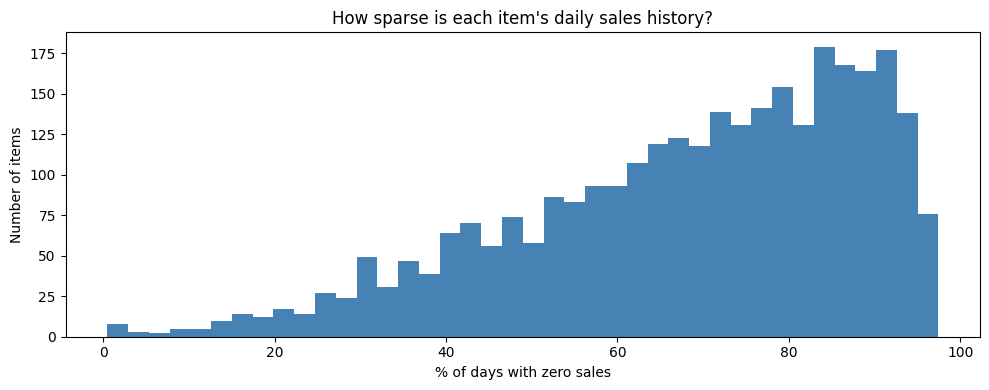

In [7]:
fig, ax = plt.subplots()
zero_share_by_item = df_long.groupby("item_id")["sales"].apply(lambda s: (s == 0).mean() * 100)
ax.hist(zero_share_by_item, bins=40, color="steelblue")
ax.set_xlabel("% of days with zero sales")
ax.set_ylabel("Number of items")
ax.set_title("How sparse is each item's daily sales history?")
plt.tight_layout()
plt.show()


Most items sit far to the right - i.e. most items have zero sales on a
large fraction of days, especially compared to state-level totals, which
are almost never exactly zero (someone always buys *something* in an
entire state on a given day). This is "intermittent demand" - a defining
feature of item-level retail data, and one of the reasons item-level
sMAPE (Section 6 of `02_pipeline.ipynb`) is so much higher than
state-level sMAPE: a handful of correct zero predictions can't rescue an
item series with, say, only 3 non-zero days out of 60 months.

Aggregating to monthly doesn't remove this sparsity, but it substantially
reduces it - a month with any sales at all is no longer zero, even if
most of the days in it were.

**Pipeline step this justifies:** daily -> monthly aggregation,
`02_pipeline.ipynb` Section 6.1.


### 4.5 The first month isn't a real month

Section 3 showed sales data starts on 2011-01-29 - only 3 days before
February. When the pipeline resamples daily data to monthly with
`pd.Grouper(freq="MS")`, those 3 days get bucketed into a `2011-01-01`
"month" alongside nothing else. That bucket isn't a partial observation
of January demand, it's a heavily undercounted one - and it's the very
first data point of four training Januaries the seasonal models will
ever see.


In [8]:
first_month_end = pd.Timestamp("2011-02-01")
days_in_first_bucket = (df_calendar["date"] >= "2011-01-29") & (df_calendar["date"] < first_month_end)
n_days_first_bucket = int(days_in_first_bucket.sum())
print(f"Days actually observed in the 2011-01-01 monthly bucket: {n_days_first_bucket} "
      f"(a normal January has 31)")

first_month_sales = df_long.loc[df_long["date"] < first_month_end, "sales"].sum()
second_month_sales = df_long.loc[
    (df_long["date"] >= first_month_end) & (df_long["date"] < "2011-03-01"), "sales"
].sum()
print(f"Total sales in the (3-day) 2011-01 bucket : {first_month_sales:,.0f}")
print(f"Total sales in the (full) 2011-02 bucket  : {second_month_sales:,.0f}")
print(f"Ratio: the first bucket holds only {first_month_sales / second_month_sales:.1%} "
      f"of a normal month's volume")


Days actually observed in the 2011-01-01 monthly bucket: 3 (a normal January has 31)
Total sales in the (3-day) 2011-01 bucket : 88,163
Total sales in the (full) 2011-02 bucket  : 726,375
Ratio: the first bucket holds only 12.1% of a normal month's volume


With `season_length=12`, ETS and Theta look for a pattern that repeats
every 12 points, using whatever monthly history they're given as the
reference. Training runs 2011-2014, so this 3-day bucket is one of only
four "Januaries" the models see - a full quarter of the seasonal
reference for that month is built from a number roughly a tenth the
size it should be. Dropping it is not discarding data so much as
refusing to mislabel 3 days as a month.

**Pipeline step this justifies:** dropping the partial first month,
`02_pipeline.ipynb` Section 6.2.


## 5. Why does the hierarchy need a "Total" root?

Look at what the three states actually roll up into.


In [9]:
n_stores_per_state = df_sales_raw.groupby("state_id")["store_id"].nunique()
print("Stores per state:")
print(n_stores_per_state)


Stores per state:
state_id
CA    4
TX    3
WI    3
Name: store_id, dtype: int64


CA has 4 stores, TX and WI have 3 each. Without an explicit "Total" node
sitting above State, the hierarchy is really **three separate trees** (one
rooted at CA, one at TX, one at WI) with no single top. Top-Down
reconciliation is only well-defined when there is one root to distribute
downward from - without it, a reconciler asked to do "Top-Down" has to
guess which of the three roots is "the top", and in practice ends up
picking whichever one aggregates the most series (CA, since it has the
most stores), then incorrectly redistributing CA's forecast across TX and
WI as well. Adding an explicit Total node - a single constant column,
`"Total"`, sitting above State - removes the ambiguity entirely.

**Pipeline step this justifies:** `col_total` / `spec`, `02_pipeline.ipynb`
Section 2. Sanity check [2] in Section 14 of that notebook confirms the
fix worked, by checking that Top-Down reconciliation leaves the Total-level
forecast completely unchanged.


## 6. New items: why fix the item universe using training data only?

Not every item was on sale for the entire 2011-2016 window - some were
introduced partway through. This section finds items with **no sales at
all** before the train/test split (2015-01-01).


In [10]:
monthly_check = (
    df_long.groupby(["item_id", pd.Grouper(key="date", freq="MS")])["sales"].sum().reset_index()
)
train_active = monthly_check.loc[
    (monthly_check["date"] < "2015-01-01") & (monthly_check["sales"] != 0), "item_id"
].unique()
all_items = monthly_check["item_id"].unique()
new_items = sorted(set(all_items) - set(train_active))

print(f"Items with zero sales before 2015-01-01: {len(new_items)} of {len(all_items):,}")
print(f"Example items: {new_items[:5]}")

if new_items:
    example = new_items[0]
    first_sale = monthly_check.loc[
        (monthly_check["item_id"] == example) & (monthly_check["sales"] > 0), "date"
    ].min()
    print(f"\nExample - '{example}' first recorded a sale in: {first_sale.date() if pd.notna(first_sale) else 'never'}")


Items with zero sales before 2015-01-01: 25 of 3,049
Example items: ['FOODS_2_185', 'FOODS_2_390', 'FOODS_3_003', 'FOODS_3_038', 'FOODS_3_047']

Example - 'FOODS_2_185' first recorded a sale in: 2015-01-01


These items simply have no training history for any model to learn from -
forecasting them would mean the model is really just guessing, not
extrapolating from a pattern. Removing them keeps the evaluation honest:
every scored forecast is for an item the models had a genuine chance to
learn from. Because this filter is applied once, at the training boundary,
before anything else is built, the test, live, and evaluation hierarchies
all end up using the exact same item set automatically - there's no later
step where they could drift apart.

**Pipeline step this justifies:** the item-universe fix in
`02_pipeline.ipynb`, Section 6.2. The count above should match that
section's printed "dropped" number.


## 7. Seasonality: is there a repeating yearly pattern?

If total sales just trend up and down randomly, `season_length=12`
wouldn't help the forecasting models at all. This plots total monthly
sales across every item and store, to check.


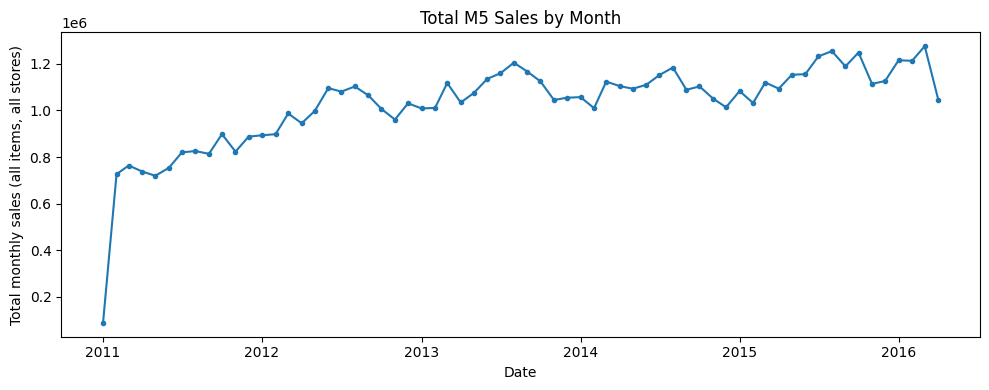

In [11]:
monthly_total = df_long.groupby(pd.Grouper(key="date", freq="MS"))["sales"].sum()

fig, ax = plt.subplots()
ax.plot(monthly_total.index, monthly_total.values, marker="o", markersize=3)
ax.set_xlabel("Date")
ax.set_ylabel("Total monthly sales (all items, all stores)")
ax.set_title("Total M5 Sales by Month")
plt.tight_layout()
plt.show()


A repeating annual pattern is visible, confirming a 12-month cycle... this justifies season_length=12

**Pipeline step this justifies:** `SEASON_LENGTH = 12`,
`02_pipeline.ipynb` Section 2 and the model setup in Section 8.


## 8. Volume concentration: the Pareto curve

Rank every item x store series by its total training-period sales, and
plot the cumulative share of volume against the cumulative share of
series. This is the same ranking the pipeline uses to build its "top p%
of volume" buckets in Section 12 of `02_pipeline.ipynb` - here it's just
visualised directly.


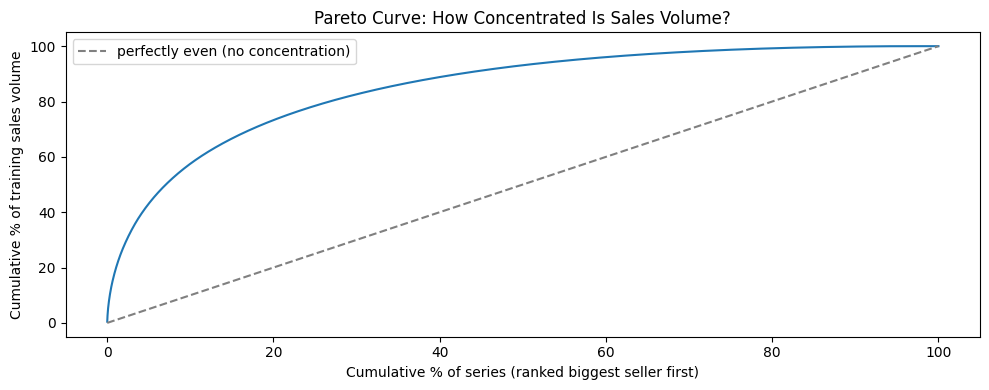

 The biggest     29 series (0.10% of all 30,490) already account for 5% of total training volume
 The biggest     94 series (0.31% of all 30,490) already account for 10% of total training volume
 The biggest    326 series (1.07% of all 30,490) already account for 20% of total training volume
 The biggest  2,151 series (7.05% of all 30,490) already account for 50% of total training volume
 The biggest  8,153 series (26.74% of all 30,490) already account for 80% of total training volume


In [12]:
train_volume = (
    df_long[df_long["date"] < "2015-01-01"]
    .groupby(["item_id", "store_id"])["sales"].sum()
    .sort_values(ascending=False)
)

cum_share_volume = train_volume.cumsum() / train_volume.sum() * 100
cum_share_series = np.arange(1, len(train_volume) + 1) / len(train_volume) * 100

fig, ax = plt.subplots()
ax.plot(cum_share_series, cum_share_volume.values)
ax.plot([0, 100], [0, 100], linestyle="--", color="gray", label="perfectly even (no concentration)")
ax.set_xlabel("Cumulative % of series (ranked biggest seller first)")
ax.set_ylabel("Cumulative % of training sales volume")
ax.set_title("Pareto Curve: How Concentrated Is Sales Volume?")
ax.legend()
plt.tight_layout()
plt.show()

for p in [5, 10, 20, 50, 80]:
    n_series = (cum_share_volume <= p).sum()
    print(f" The biggest {n_series:>6,} series ({n_series/len(train_volume):5.2%} of all "
          f"{len(train_volume):,}) already account for {p}% of total training volume")


The steep curve is the point: a small number of series account for a
disproportionate share of total sales, and the vast majority of series
(the long tail) contribute very little individually. This is the concrete
evidence behind the thesis's founding motivation - that forecast accuracy
for high-volume, business-critical series matters more than treating every
series equally.

**Pipeline step this justifies:** the volume-bucket evaluation in
`02_pipeline.ipynb`, Section 12 - and explains why "top 5% of volume" ends
up being a tiny number of series, not 5% of the item list.


## 9. Sales by category and state

A simple descriptive breakdown, useful for background context in the
thesis (e.g. which category dominates revenue, whether states are
comparable in scale).


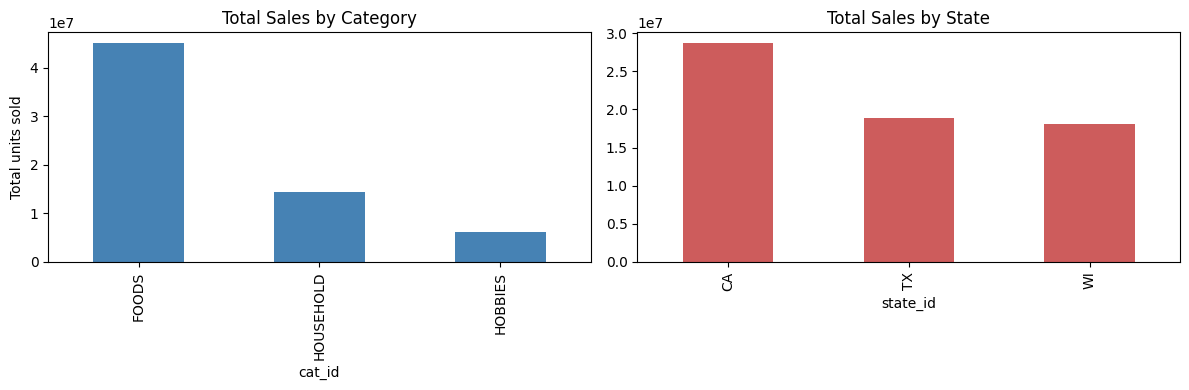

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df_long.groupby("cat_id")["sales"].sum().sort_values(ascending=False).plot(
    kind="bar", ax=axes[0], color="steelblue"
)
axes[0].set_title("Total Sales by Category")
axes[0].set_ylabel("Total units sold")

df_long.groupby("state_id")["sales"].sum().sort_values(ascending=False).plot(
    kind="bar", ax=axes[1], color="indianred"
)
axes[1].set_title("Total Sales by State")

plt.tight_layout()
plt.show()


### 9.5 Sales are never negative - so why does the pipeline clip forecasts?

Every check so far has been about the shape of demand. This one is about
a constraint on it: units sold cannot be negative. That sounds obvious,
but it matters because the base forecasting models (ETS, Theta) have no
awareness of it - they are free to extrapolate a downward trend straight
through zero. This section simply confirms the raw data itself respects
the constraint the models don't.


In [14]:
n_negative_raw = (df_long["sales"] < 0).sum()
print(f"Negative values in the raw daily sales data: {n_negative_raw:,} "
      f"(of {len(df_long):,} observations)")
print(f"Minimum observed daily sales value: {df_long['sales'].min()}")


Negative values in the raw daily sales data: 0 (of 58,327,370 observations)
Minimum observed daily sales value: 0


As expected, the raw data has no negative values - a day either has 0
or more units sold, nothing else. Any negative number that later shows
up in a *forecast* is therefore known, with certainty, to be an
artefact of the model rather than a real possibility being predicted.
That's a stronger justification for clipping than "negative sales look
odd" - it's "negative sales are not a value this series can take".

**Pipeline step this justifies:** clipping base forecasts at 0 before
reconciliation, `02_pipeline.ipynb` Section 8.5. (Section 13 of that
notebook shows how often ETS and Theta actually produced negative values
before the clip was added: 2,796 and 21,768 rows respectively.)


## 10. Summary: EDA Findings $\rightarrow$ Pipeline Decisions

* **Sales data ends ~April 2016; calendar extends further** $\rightarrow$ Live window described honestly as "extended beyond available data", never scored.
* **Sales data *starts* mid-month, leaving a 3-day "January" (Section 4.5)** $\rightarrow$ Drop the partial first calendar month before modelling.
* **Item-level daily data is highly sparse (Section 4)** $\rightarrow$ Aggregate daily to monthly before modelling.
* **CA/TX/WI are three separate hierarchy roots (Section 5)** $\rightarrow$ Add an explicit "Total" root above State.
* **Some items have zero sales before 2015 (Section 6)** $\rightarrow$ Fix the item universe once, from training data only.
* **Total sales show a repeating yearly pattern (Section 7)** $\rightarrow$ Use `season_length=12` in ETS and Theta.
* **Sales volume is highly concentrated (Section 8)** $\rightarrow$ Evaluate accuracy separately by volume segment, ranked on training data only.
* **Raw sales are never negative (Section 9.5)** $\rightarrow$ Clip base forecasts at 0 before reconciliation.

---

> Everything in `02_pipeline.ipynb` traces back to one of the mappings above.